In [46]:
import torch
from torch import nn
import sklearn
from sklearn.datasets import make_circles
import pandas as pd

# make 1000 samples

n_samples = 1000

X,y=make_circles(n_samples,
                noise=0.03,
                random_state=42)

circles = pd.DataFrame({
    "X1":X[:,0],
    "X2":X[:,1],
    "label":y
})

In [48]:
# check input and output shape

# turn the data into a tensor
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)


In [49]:
# split the data into training and test data

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

x_train,y_train=x_train.to(device),y_train.to(device)
x_test,y_test=x_test.to(device),y_test.to(device)

torch.cuda.manual_seed(42)


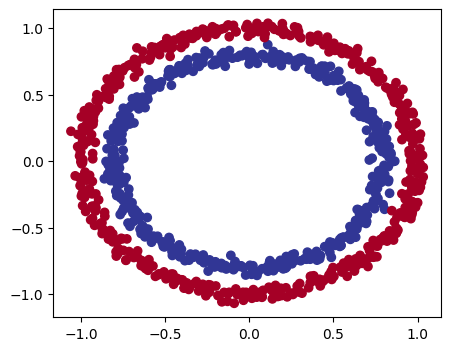

In [18]:
# visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu
           );

In [25]:
class circle_classfication_model(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1=nn.Linear(in_features=2,out_features=8)
        self.ac1=nn.ReLU()
        self.layer_2=nn.Linear(in_features=8,out_features=1)

        # self.layers=nn.Sequential(
        #     nn.Linear(2,8)
        #     nn.Linear(8,1)
   
        # )
        # def forward(self,x):
        #     return self.layers(x);

    def forward(self,x):
        return self.layer_2(self.ac1(self.layer_1(x)))


# Build a Model
device = "cuda" if torch.cuda.is_available() else "cpu"

model_0=circle_classfication_model().to(device)
model_0.state_dict()


OrderedDict([('layer_1.weight',
              tensor([[ 0.2636, -0.1480],
                      [ 0.2974,  0.3714],
                      [-0.0188, -0.0404],
                      [-0.6625, -0.2967],
                      [ 0.3122,  0.5564],
                      [-0.5449,  0.4095],
                      [ 0.4751,  0.6898],
                      [ 0.3342, -0.2653]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.0959,  0.3473,  0.5614,  0.3071,  0.1529, -0.0926,  0.2736, -0.2282],
                     device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.2089, -0.0020,  0.2792,  0.2442,  0.0532,  0.2746,  0.3223, -0.2828]],
                     device='cuda:0')),
             ('layer_2.bias', tensor([0.2965], device='cuda:0'))])

###**Notes:**
**`nn.BCEWithLogitsLoss`** expects raw logits as input
 
`nn.BCELoss` expects propabilities, where prob = torch.sigmoid(logits) 


In [22]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.05)

# caculate accuracy 
def accuracy_fn(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred)) * 100
    return acc/100

def train_test_loop(epochs=100):
    for epoch in range(epochs):
        
        model_0.train()
    
        # 1. forward pass - squeeze both
        y_logits = model_0(x_train).squeeze()  # [batch]
        y_pred = torch.round(torch.sigmoid(y_logits))
    
        # 2. calculate the loss - squeeze y_train too
        train_loss = loss_fn(y_logits, y_train.squeeze())  # Both [batch]
        train_acc = accuracy_fn(y_train.squeeze(), y_pred)
    
        # 3. optimizer zero grad
        optimizer.zero_grad()
    
        # 4. loss backward
        train_loss.backward()
    
        # 5. gradient descent
        optimizer.step()
    
        # ===Testing loop====
        model_0.eval()
        with torch.inference_mode():
            test_logits = model_0(x_test).squeeze()
            y_test_preds = torch.round(torch.sigmoid(test_logits))
            
            test_loss = loss_fn(test_logits, y_test.squeeze())
            test_acc = accuracy_fn(y_test.squeeze(), y_test_preds)
            
        if epoch % 100 == 0:
            print(f"epoch=:{epoch} | train_loss={train_loss:.4f} | train_acc={train_acc:.2f}% | test_loss={test_loss:.4f} | test_acc={test_acc:.2f}%")

In [24]:
train_test_loop(1000)

epoch=:0 | train_loss=0.6549 | train_acc=0.69% | test_loss=0.6639 | test_acc=0.63%
epoch=:100 | train_loss=0.6483 | train_acc=0.72% | test_loss=0.6590 | test_acc=0.67%
epoch=:200 | train_loss=0.6412 | train_acc=0.75% | test_loss=0.6534 | test_acc=0.69%
epoch=:300 | train_loss=0.6333 | train_acc=0.79% | test_loss=0.6473 | test_acc=0.72%
epoch=:400 | train_loss=0.6248 | train_acc=0.81% | test_loss=0.6407 | test_acc=0.75%
epoch=:500 | train_loss=0.6154 | train_acc=0.85% | test_loss=0.6331 | test_acc=0.76%
epoch=:600 | train_loss=0.6054 | train_acc=0.86% | test_loss=0.6252 | test_acc=0.81%
epoch=:700 | train_loss=0.5949 | train_acc=0.88% | test_loss=0.6166 | test_acc=0.81%
epoch=:800 | train_loss=0.5840 | train_acc=0.89% | test_loss=0.6076 | test_acc=0.81%
epoch=:900 | train_loss=0.5728 | train_acc=0.89% | test_loss=0.5984 | test_acc=0.82%
